In [18]:
# import stuff
import asymmetree.treeevolve as te
from asymmetree.visualization.tree_vis import visualize, assign_colors
import bmg_fun
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import graphviz_layout
from collections import defaultdict
import random
import matplotlib.gridspec as gridspec
import insert_hybrid
from asymmetree.analysis.best_matches import lrt_from_colored_graph
from lrt_fun import lrt_from_bmg
import BICcherryRestrict
from simplifying_operations import beam_search_step
from simplifying_operations import greedy_search
import numpy as np
from bmg_Tony import bmg

In [2]:
# set seed
# Setze den Seed für Pythons Standard-Zufallsfunktionen
random.seed(3)
# Setze den Seed für NumPys Zufallsfunktionen (wichtig für AsymmeTree)
np.random.seed(3)

# species tree
S = te.species_tree_n_age(
    4, 1.0, contraction_probability=0.0, contraction_proportion=0.2, contraction_bias="exponential"
)
# gene tree
T = te.dated_gene_tree(
    S, dupl_rate=1.0, loss_rate=0, hgt_rate=0.2, gc_rate=0.2, prohibit_extinction="per_species", dupl_polytomy=0.5
)
# prune all loss branches and the planted root
observable_gene_tree = te.prune_losses(T)
#visualize(T, color_dict=gene_colors) 

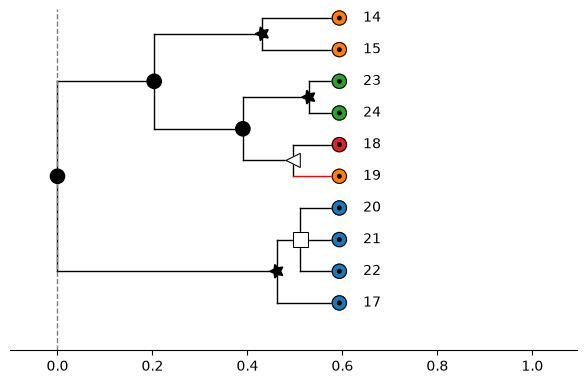

In [3]:
# get color dicts
species_colors, gene_colors = assign_colors(S, observable_gene_tree)
# visualize asymetree tree
visualize(observable_gene_tree, color_dict=gene_colors) 

In [4]:
# convert to networkx
tree_to_nx = bmg_fun.convert_to_nx(observable_gene_tree)
network = insert_hybrid.insertHybrid(tree_to_nx, 5)

In [5]:
#print(tree_to_nx.nodes(data=True))

In [6]:
# reverse dict so every color has a list of leaves attached to it, for visualization
color_to_keys = defaultdict(list)
for key, color in gene_colors.items():
    color_to_keys[tuple(color)].append(key)

Text(0.5, 1.0, 'Hybrid Network')

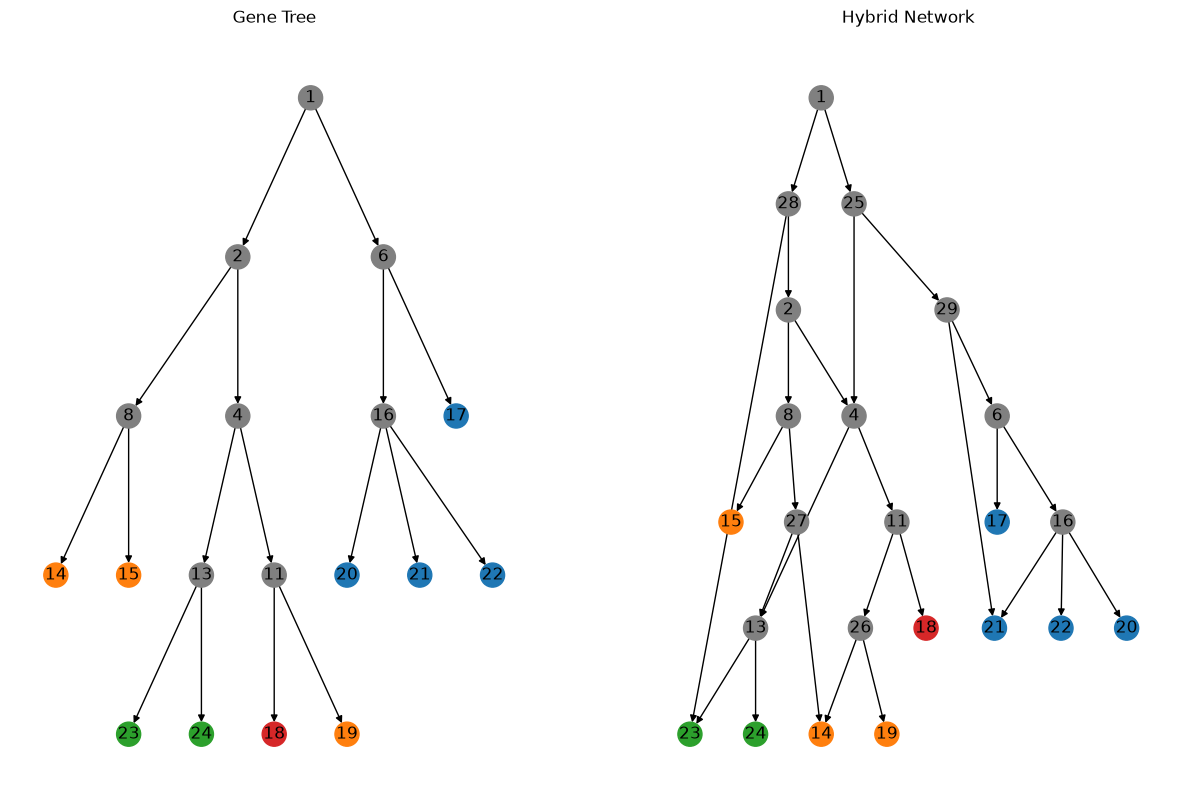

In [7]:
# gene color dict turn keys to strings
gene_colors_str = {str(k): v for k, v in gene_colors.items()}

# visualize tree and network
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

pos = graphviz_layout(tree_to_nx, prog="dot")
nodes_list = [v for v in tree_to_nx.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]

nx.draw(tree_to_nx, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0])
axes[0].set_title("Gene Tree")


pos = graphviz_layout(network, prog="dot")
nodes_list = [v for v in network.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(network, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[1])
axes[1].set_title("Hybrid Network")

# 02 Simplification of explaining networks
Construct tree-BMGs (G, σ) from (AsymmeTree-generated) trees and compute their least resolved trees T . This is the target.

In [8]:
# BMGs mit Tonys Funktion
BMG_tree_tony = bmg(tree_to_nx)
BMG_network_tony = bmg(network, mode="weak")


Text(0.5, 1.0, 'Network BMG Tony')

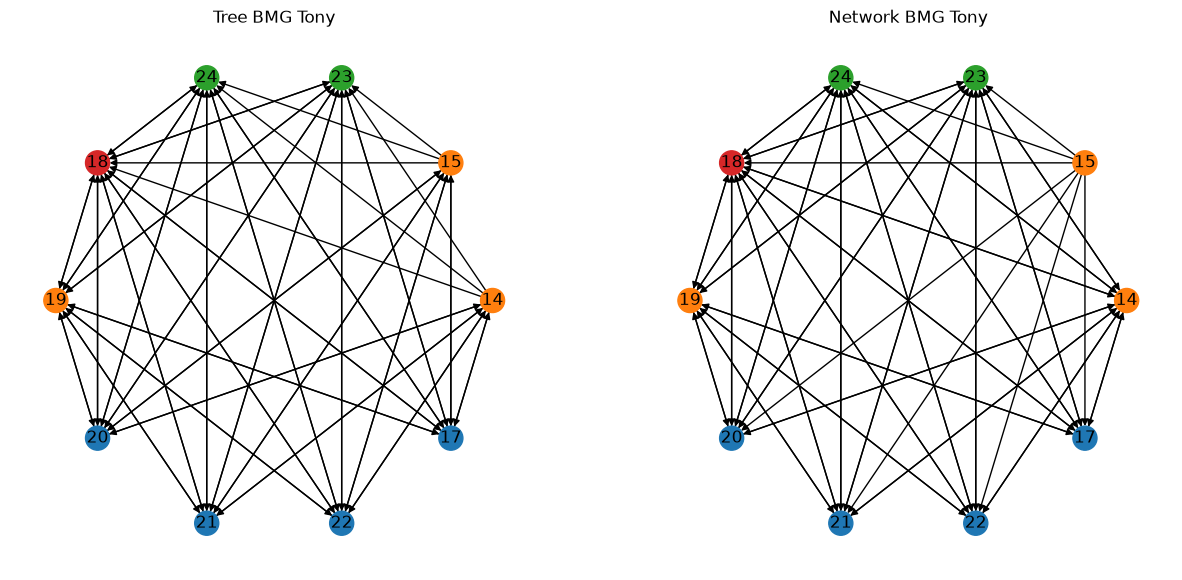

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Nach Tonys Funktion
nodes_list = [v for v in BMG_tree_tony.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(BMG_tree_tony, nx.circular_layout(BMG_tree_tony), nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Tree BMG Tony")

# network BMG
nodes_list = [v for v in BMG_network_tony.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(BMG_network_tony, nx.circular_layout(BMG_network_tony), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels=True)
axes[1].set_title("Network BMG Tony")
    


## Least resolved tree

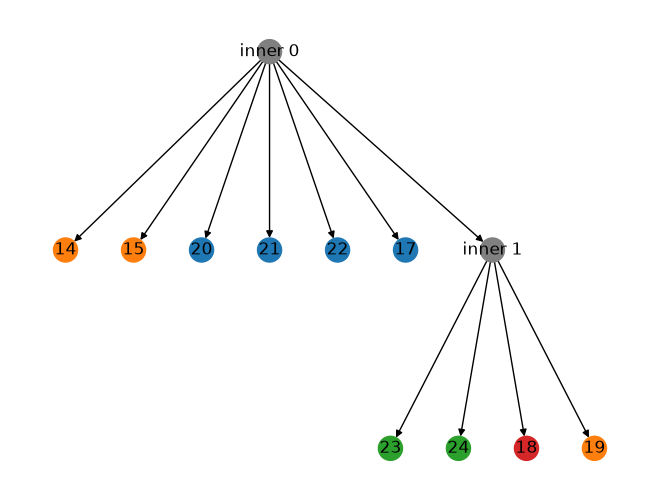

In [10]:
# lrt
our_lrt = lrt_from_bmg(BMG_tree_tony)

fig = plt.figure()
pos = graphviz_layout(our_lrt, prog="dot")
nodes_list = [v for v in our_lrt.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(our_lrt, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True)

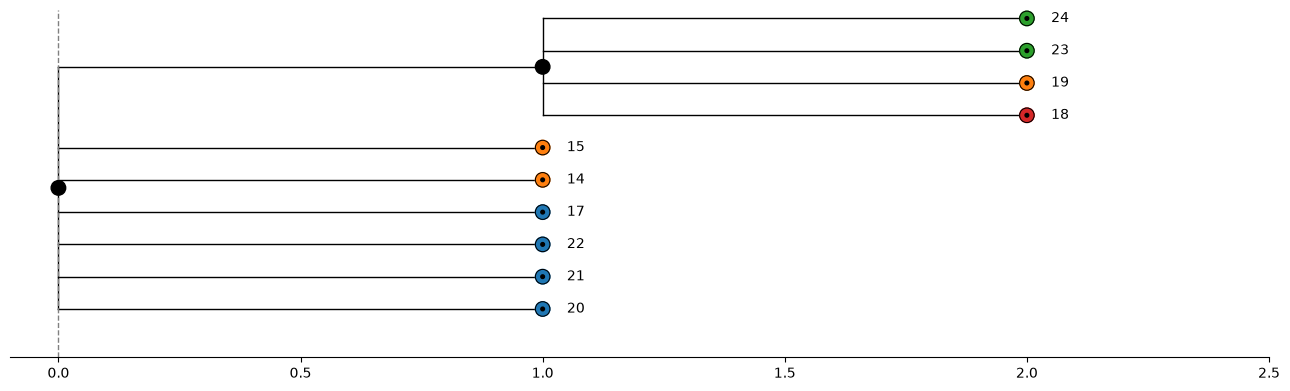

In [11]:
from asymmetree.analysis.best_matches import lrt_from_tree
# least resolved tree from pruned tree
lrt = lrt_from_tree(observable_gene_tree)

visualize(lrt, color_dict=gene_colors) 

In [12]:
# Problem with lrt from Asymetree: inner nodes names are emtpy strings!
for u, v, sibling_nr in lrt.edges_sibling_order():
    #print(type(u.label))
    print(f"edge between {u} and {v}")

edge between  and 
edge between  and 24
edge between  and 23
edge between  and 19
edge between  and 18
edge between  and 15
edge between  and 14
edge between  and 17
edge between  and 22
edge between  and 21
edge between  and 20


## Thinness classes
Combining leaves in BMG to create thinness classes and reduce the amount of necessary work.

Text(0.5, 1.0, 'Thinness class BMG')

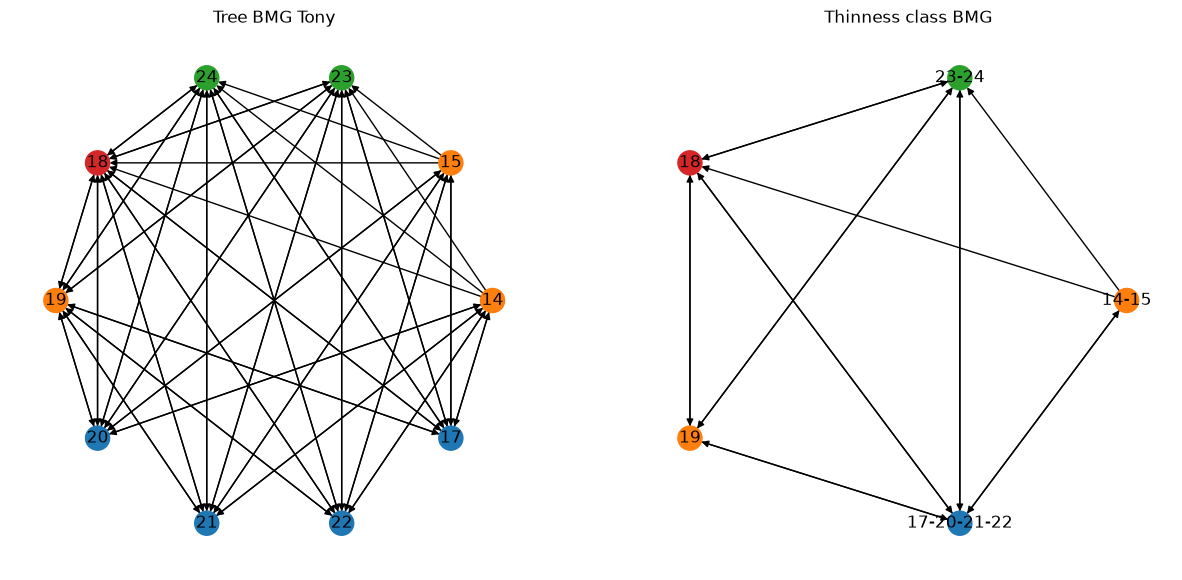

In [13]:
thin_BMG, thin_gene_colors = bmg_fun.thinness_graph(BMG_tree_tony, gene_colors_str)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Nach Tonys Funktion
nodes_list = [v for v in BMG_tree_tony.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(BMG_tree_tony, nx.circular_layout(BMG_tree_tony), nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Tree BMG Tony")

# thinness BMG
nodes_list = [v for v in thin_BMG.nodes()]
#nodes_colors = [thin_BMG.nodes[v]["color"] for v in nodes_list]
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(thin_BMG, nx.circular_layout(thin_BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels=True)
axes[1].set_title("Thinness class BMG")

Text(0.5, 1.0, 'Thinness class LRT')

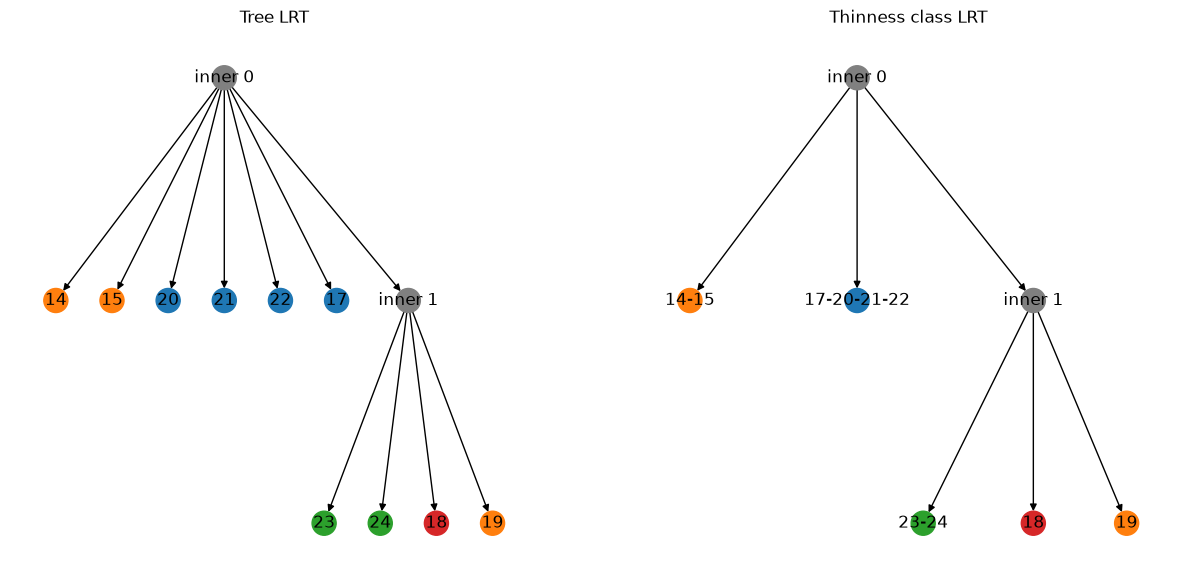

In [14]:
# just for funsies, a comparison between the two lrts
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Ursprünglicher lrt
pos = graphviz_layout(our_lrt, prog="dot")
nodes_list = [v for v in our_lrt.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(our_lrt, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Tree LRT")

# thinness class lrt
thin_lrt = lrt_from_bmg(thin_BMG)
nodes_list = [v for v in thin_lrt.nodes()]
pos = graphviz_layout(thin_lrt, prog="dot")
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(thin_lrt, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels=True)
axes[1].set_title("Thinness class LRT")

Text(0.5, 1.0, 'Thinness class Bic Cherry')

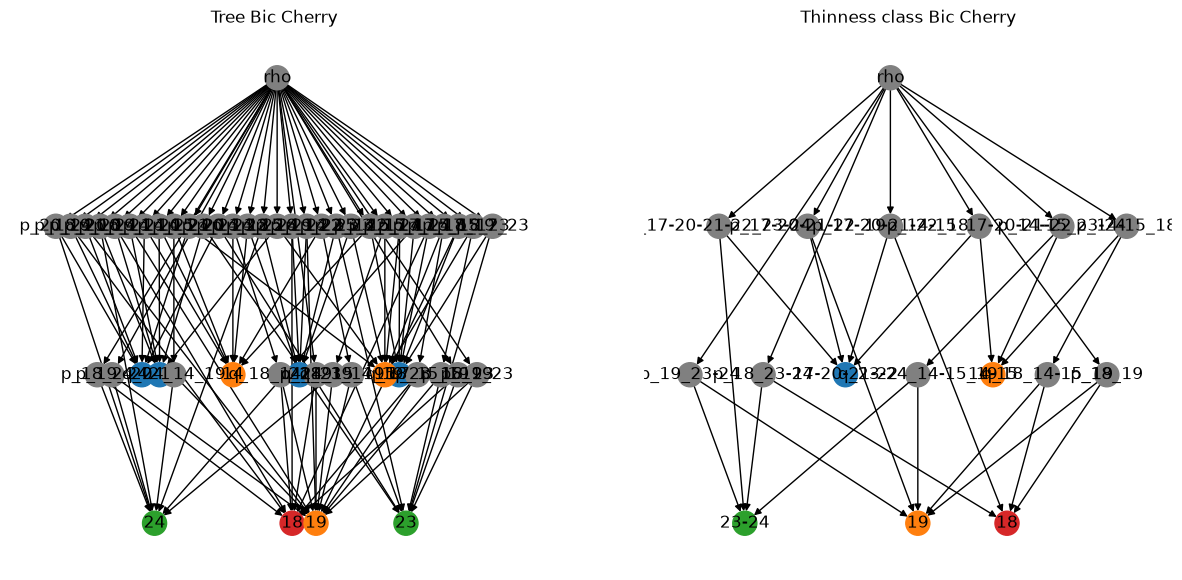

In [20]:
bic_cherry_tree = BICcherryRestrict.BICcherryRestrict(BMG_tree_tony)
thin_bic_cherry_tree = BICcherryRestrict.BICcherryRestrict(thin_BMG)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Ursprünglicher lrt
pos = graphviz_layout(bic_cherry_tree, prog="dot")
nodes_list = [v for v in bic_cherry_tree.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(bic_cherry_tree, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Tree Bic Cherry")

# thinness class lrt
nodes_list = [v for v in thin_bic_cherry_tree.nodes()]
pos = graphviz_layout(thin_bic_cherry_tree, prog="dot")
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(thin_bic_cherry_tree, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels=True)
axes[1].set_title("Thinness class Bic Cherry")

simplifying step 1/100
simplifying step 2/100
simplifying step 3/100
simplifying step 4/100
added cherry edge {'p_15_22', 'p_15_23', 'p_15_17', 'p_15_24', 'p_15_20', 'p_15_21', 'p_15_18'} - 14
simplifying step 5/100
simplifying step 6/100
simplifying step 7/100
simplifying step 8/100
simplifying step 9/100
simplifying step 10/100
simplifying step 11/100
added cherry edge {'p_18_24', 'p_20_24', 'q_24_15_19', 'p_21_24', 'p_17_24', 'p_22_24'} - 23
simplifying step 12/100
simplifying step 13/100
simplifying step 14/100
simplifying step 15/100
simplifying step 16/100
simplifying step 17/100
simplifying step 18/100
simplifying step 19/100
simplifying step 20/100
simplifying step 21/100
simplifying step 22/100
simplifying step 23/100
added cherry edge {'p_19_21', 'p_18_21', 'p_21_24', 'p_15_21'} - 20
simplifying step 24/100
simplifying step 25/100
simplifying step 26/100
simplifying step 27/100
simplifying step 28/100
added cherry edge {'p_15_22', 'p_18_22', 'p_19_22', 'p_22_24'} - 20
simplif

Text(0.5, 1.0, 'Thinness class Greedy tree')

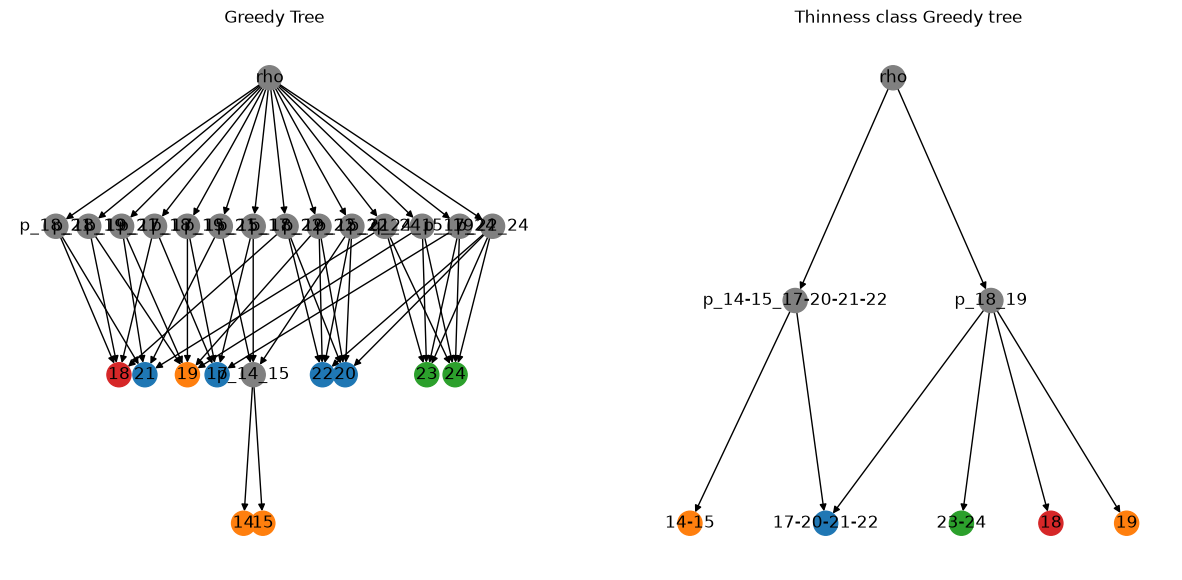

In [21]:
greedy_tree = greedy_search(bic_cherry_tree)
thin_greedy_tree = greedy_search(thin_bic_cherry_tree)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Ursprünglicher lrt
pos = graphviz_layout(greedy_tree, prog="dot")
nodes_list = [v for v in greedy_tree.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(greedy_tree, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Greedy Tree")

# thinness class lrt
nodes_list = [v for v in thin_greedy_tree.nodes()]
pos = graphviz_layout(thin_greedy_tree, prog="dot")
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(thin_greedy_tree, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels=True)
axes[1].set_title("Thinness class Greedy tree")

In [28]:
nx.graph_edit_distance(thin_greedy_tree, thin_lrt)

5.0

Text(0.5, 1.0, 'Thinness class BMG')

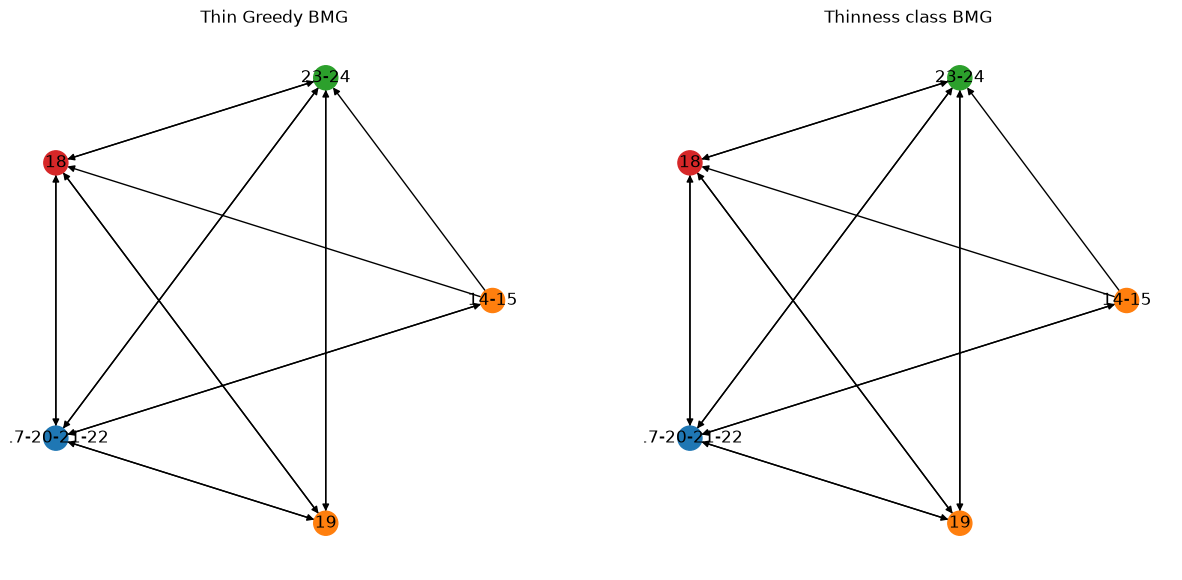

In [24]:
thin_greedy_BMG = bmg(thin_greedy_tree)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Nach Tonys Funktion
pos = nx.circular_layout(thin_greedy_BMG)
nodes_list = [v for v in thin_greedy_BMG.nodes()]
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(thin_greedy_BMG, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[0], with_labels=True)
axes[0].set_title("Thin Greedy BMG")

# thinness BMG
nodes_list = [v for v in thin_BMG.nodes()]
#nodes_colors = [thin_BMG.nodes[v]["color"] for v in nodes_list]
nodes_colors = [thin_gene_colors.get(v, "grey") for v in nodes_list]
nx.draw(thin_BMG, pos, nodelist=nodes_list, node_color= nodes_colors, ax=axes[1], with_labels=True)
axes[1].set_title("Thinness class BMG")

## 2b Take the tree-BMGs from (a) and construct the BIC-cherry+expansion explanations

In [11]:
# ignore least resolved tree for now
# we need a function for that!!!!
bic_cherry_tree = BICcherry.BICcherry(BMG_network_tony)

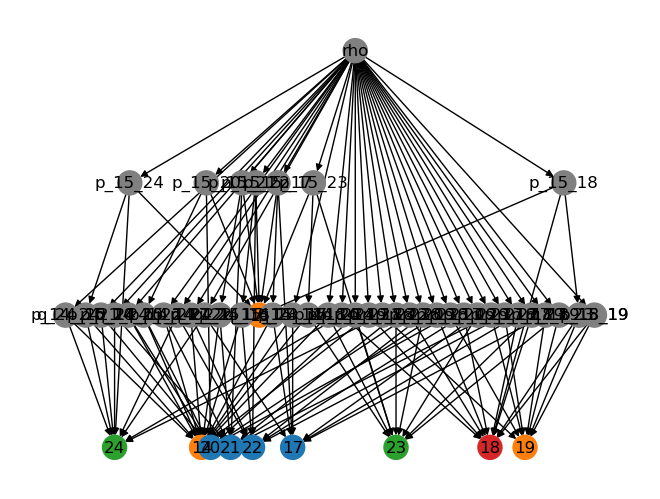

In [12]:
# turn LRT into networkx graph
#lrt_to_nx = bmg_fun.convert_to_nx(lrt)
fig = plt.figure()
pos = graphviz_layout(bic_cherry_tree, prog="dot")

nodes_list = [v for v in bic_cherry_tree.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(bic_cherry_tree, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels=True)

In [13]:
print("Weak BMGs equal? ", nx.utils.graphs_equal(BMG_network_tony, bmg(bic_cherry_tree, mode="weak")))
print("Weak BMGs equal? ", nx.utils.graphs_equal(bmg(network, mode="strong"), bmg(bic_cherry_tree, mode="strong")))

Weak BMGs equal?  True
Weak BMGs equal?  True


## Up is Down
(c) Implement graph editing by “pulling up” or “pulling down” edges, and removing vertices with the same parents and children, as described in class.

(d) Check both for single moves and combinations of a small number of moves whether the modified network (N ′ , σ) has the same (weak) best match graph as (N, σ).

We now seek to simplify this network to a tree-like structure with beam search

Finished step 1/1


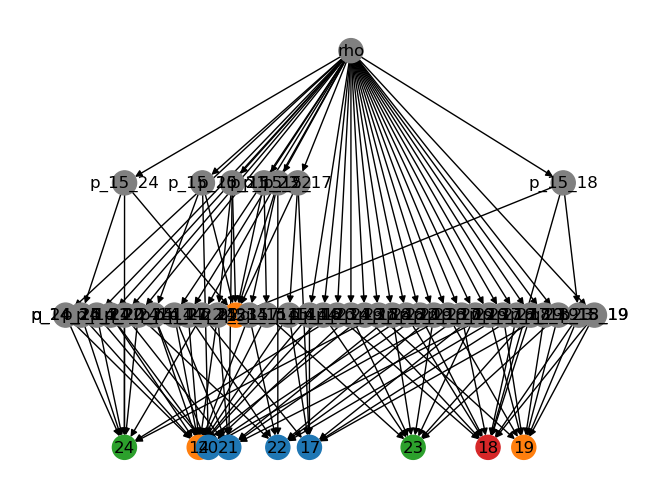

In [18]:
from simplifying_operations import beam_search

reconstructed_tree = beam_search(bic_cherry_tree, max_number_of_steps=1, top_n= 1, mode = "weak")[0]
pos = graphviz_layout(reconstructed_tree, prog="dot")
nodes_list = [v for v in reconstructed_tree.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list] #???
nx.draw(reconstructed_tree, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels=True)

# TODOs
- Develop heuristics
- improve efficiency of beam_search_step()